##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

**Load and merge datasets**

In [45]:
df_ship_inventory = pd.read_csv('ship_inventory.csv')
df_ship_inspection = pd.read_csv('ship_inspections_iter2.csv')

df_merged = df_ship_inventory.merge(df_ship_inspection, left_on="Ship_ID", right_on="Ship_ID", how="left")
df_merged.head()

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle


We have decided to merge the original version of ship inventory here, because in Iteration 1, we have cleaned the data by deleting NaN's, but that means we lost a lot of rows. With our new gained knowledge we decided it would be the best to start from the scratch and fill the missing values based on rest of the data.

---

## 1. Business Understanding

### Situation Description

Nebula Brokerage needs a reliable way to assess the technical condition of ships before they are sold, priced, or flagged for further inspection. However, the available data is fragmented across two separate files: one file contains the ship inventory information, while the other contains inspection data. Because these datasets are disconnected, the company does not immediately have one complete overview of each ship.

In addition, the new inspection dataset contains several data quality issues. The `Propulsion_Type` column has many missing values due to a sensor malfunction, while `Reactor_Power` contains both missing values and suspiciously extreme values that may represent illegal overclocked reactors. These problems reduce trust in the data and make it difficult to use directly for decision-making.

A further business problem is that the data does not include a simple condition label that can be used by non-technical employees. Sales staff may see raw technical values, but without a clear rating such as **Pristine**, **Operational**, or **Critical**, they may underestimate risks, overprice damaged ships, or recommend unsafe vessels to customers. This creates financial, legal, and reputational risk for Nebula Brokerage.

### Business Objective

The business objective is to create a reliable and easy-to-understand ship condition rating that supports sales, risk screening, and pricing decisions. Nebula Brokerage wants each ship to be classified into one of three categories: **Pristine**, **Operational**, or **Critical**.

This rating should help the company quickly identify ships that are in excellent condition, ships that are still usable but may need attention, and ships that represent a high risk. A consistent rating system improves decision-making, reduces the chance of unsafe ships being sold as healthy inventory, and gives the sales team a practical output they can use without interpreting raw engineering data.

### Data Mining Goal

The data mining goal is to build a **manual rule-based classification model** that predicts ship condition using the available ship and inspection attributes. This is a **multiclass classification** task, because each ship must be assigned to exactly one of three categories: **Pristine**, **Operational**, or **Critical**.

The model should use business-relevant variables such as `Model_Cycle`, `Galactic_Credits`, `Propulsion_Type`, and `Reactor_Power`, because these features are expected to reflect both the age and value of a ship as well as important technical indicators of condition. Since the assignment explicitly asks for a manual model, the focus is not on training a machine learning algorithm, but on creating clear business rules that can be explained and justified.

### Success Criteria

#### Data Success Criteria

The dataset preparation will be considered successful when:
- The inventory and inspection data are merged correctly using `Ship_ID`.
- Missing values in the new inspection columns are handled with a justified imputation strategy.
- Suspicious `Reactor_Power` outliers are identified and treated appropriately.
- The cleaned dataset contains the required variables for analysis and modeling.
- The final prepared dataset is saved so it can be reused in iteration 3.

#### Model Success Criteria

The model will be considered successful when:
- Every ship receives exactly one condition label: **Pristine**, **Operational**, or **Critical**.
- The rules are transparent, logically ordered, and based on findings from the data understanding phase.
- The model uses the required features `Model_Cycle` and `Galactic_Credits`, and also incorporates `Propulsion_Type` and `Reactor_Power`.
- The predicted labels show a realistic distribution, meaning the model does not classify almost all ships into a single category.
- The model performs reasonably well when compared with the real `Hull_Integrity` values using classification metrics and a confusion matrix.

#### Business Success Criteria

From a business perspective, the project is successful when the output is useful for operational decision-making. In practice, this means the model should especially help identify risky ships early, support more consistent pricing and sales decisions, and reduce the chance that ships in poor condition are treated as healthy stock. A model that is slightly conservative is acceptable, as long as it avoids dangerous errors such as labeling truly critical ships as safe.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [46]:
df_merged.info()
df_merged.duplicated(subset=["Ship_ID"]).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  object 
 4   Sector             368814 non-null  object 
 5   Hull_Integrity     368814 non-null  object 
 6   Reactor_Power      339345 non-null  float64
 7   Propulsion_Type    312108 non-null  object 
 8   Ship_Class         368814 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 25.3+ MB


500

Looking at the data we can see that there are 368814 total rows. Out of those Model_Cycle is missing 7406 values, Reactor_Power is missing 29469 entries and Propulsion_Type is missing 56706 values. These missing values could potentionally skew with the statistics.

We also check for duplicates, which shows 500 of them.

In [47]:
df_merged = df_merged.drop_duplicates(subset=["Ship_ID"], keep="first")
df_merged.duplicated(subset=["Ship_ID"]).sum()

0

We start cleaning the data by first removing all the duplicates.

In [48]:
df_merged.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,3.683140e+05,368314.000000,360916.000000,338876.000000
mean,7.311484e+09,19454.237615,7511.263984,71.592559
std,4.381194e+06,15542.661057,9.079721,44.644147
min,7.301583e+09,501.000000,7400.000000,30.000000
25%,7.308103e+09,7950.000000,7508.000000,40.000000
50%,7.312604e+09,15990.000000,7513.000000,60.000000
75%,7.315244e+09,27990.000000,7517.000000,80.000000
max,7.317101e+09,777777.000000,7522.000000,360.000000


Galactic Credits: The median price is 15990, but the mean is 19454, because of extreme outliers, as the maximum value is 777777. This is also reflected in the large standard deviation 15542.

Model Cycle: The ships range from cycle 7400 to 7522. The distribution is heavily skewed toward newer models, with 75% of the data concentrated between cycle 7508 and 7522.

Reactor Power: The power levels range from a minimum of 30 to a maximum of 360. While 75% of the ships have a reactor power of 80 or less, the maximum value of 360 indicates the presence of severe outliers on the high end.

In [49]:
df_merged["Ship_Manufacturer"].unique()

array(['Galactic Motors', 'Republic Aerospace', 'Nebula Industries',
       'Corellian Engineering', 'General Mining Corp', 'Hondo Systems',
       'Bayerische Motoren Wormhole', 'Independent Shipwrights',
       'Kuat Drive Yards', 'Droid Works', 'Mercurian Benz',
       'Galactic Motors ', 'Jumpship Corp', 'Independent Shipwright',
       'Independent', 'Kuat Drive', 'Galactic_Motors', 'Ind. Shipwrights',
       'Corellian Eng.', 'Kuat  Drive Yards', 'Galactic Motrs',
       'Nebula Ind', 'Corellian Engineering Corp', 'Nebula',
       'Nebula Industries (c)', 'Corelian Engineering', 'GALACTIC MOTORS',
       'Kuat DY'], dtype=object)

Since we will later be using Ship_Manufacturer and we need to correctly visualize the data, we will check for typos, different wording and other mistakes using unique.

In the result we can see there are quite a few mistakes so we will fix them in the next step.

In [50]:
normalize = {
    "Galactic Motors ": "Galactic Motors",
    "GALACTIC MOTORS": "Galactic Motors",
    "Galactic_Motors": "Galactic Motors",
    "Galactic Motrs": "Galactic Motors",

    "Nebula Industries (c)": "Nebula Industries",
    "Nebula Ind": "Nebula Industries",
    "Nebula": "Nebula Industries",

    "Corellian Engineering Corp": "Corellian Engineering",
    "Corellian Eng.": "Corellian Engineering",
    "Corelian Engineering": "Corellian Engineering",

    "Independent Shipwright": "Independent Shipwrights",
    "Ind. Shipwrights": "Independent Shipwrights",
    "Independent": "Independent Shipwrights",

    "Kuat  Drive Yards": "Kuat Drive Yards",
    "Kuat Drive": "Kuat Drive Yards",
    "Kuat DY": "Kuat Drive Yards",
}

df_merged["Ship_Manufacturer"] = (
    df_merged["Ship_Manufacturer"]
      .map(lambda x: normalize.get(x, x))
)

df_merged["Ship_Manufacturer"].unique()

array(['Galactic Motors', 'Republic Aerospace', 'Nebula Industries',
       'Corellian Engineering', 'General Mining Corp', 'Hondo Systems',
       'Bayerische Motoren Wormhole', 'Independent Shipwrights',
       'Kuat Drive Yards', 'Droid Works', 'Mercurian Benz',
       'Jumpship Corp'], dtype=object)

First we created a dictionary where we map all the mistakes to the correct version of the Ship_Manufacturer. After that we run through all the rows and check if the spelling is correct and in case it isn't we map it to the correct one.

By using the unique command again we check if we have correctly mapped all the Ship_Classes, which we did.

**Visualizations and patterns**


Hull_Integrity
Critical       80.966825
Operational    62.849822
Pristine       72.730196
Name: Reactor_Power, dtype: float64

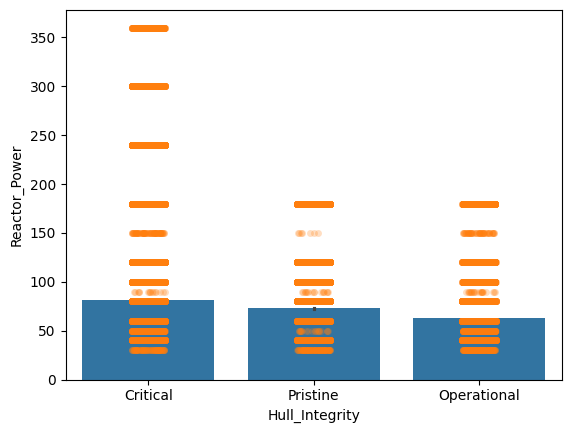

In [51]:
sns.barplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", estimator='mean')
sns.stripplot(data=df_merged, x="Hull_Integrity", y="Reactor_Power", alpha=0.25, jitter=True)
df_merged.groupby("Hull_Integrity")["Reactor_Power"].mean()


On this plot we can see that the reactors with more power are more likely to have a critical hull condition. We can also see that majority of outliers are in critical condition.

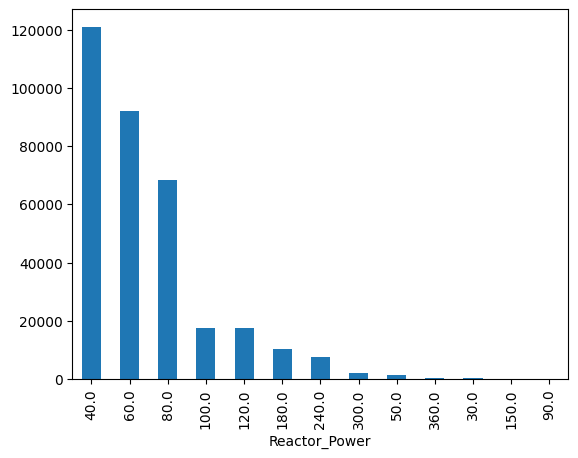

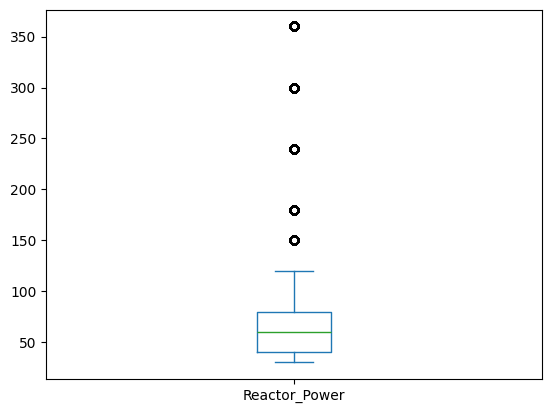

In [52]:
df_merged["Reactor_Power"].value_counts().plot.bar()
plt.show()

df_merged["Reactor_Power"].plot.box()
plt.show()


On the first plot we can see that majority of the ships are 80 or below reactor power. This bar blot doesnt really help us with identifying the outliers though, so we also chose to create a box plot. This seconnd plot clearly shows us that all the reactors above 120 reactor power are otliers and therefore we can classify them as illegal reactors.

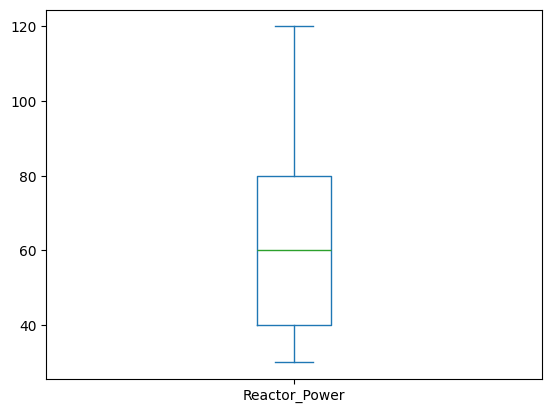

In [53]:
df_merged = df_merged[df_merged["Reactor_Power"] <= 120]
df_merged["Reactor_Power"].plot.box()
plt.show()


We have decided to remove all the reactors above 120 reacotr power, to prevent data skewage and to also adhere to safety risks by removing overclocked reactors.
On the box plot we can now clearly see all the outliers are gone.

Text(0.5, 1.0, 'Count of Ship in based on Hull Integrity')

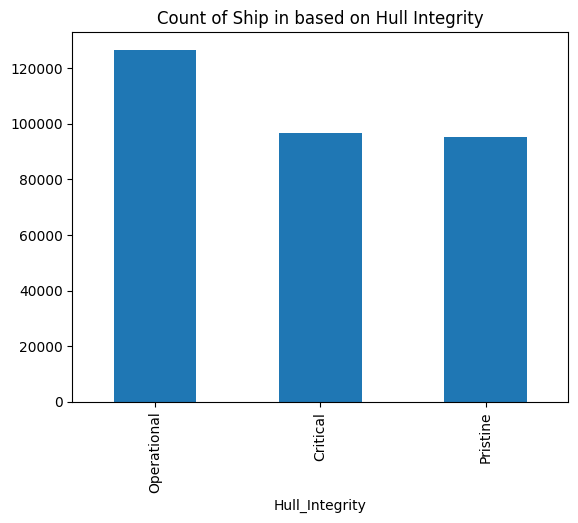

In [54]:
df_merged["Hull_Integrity"].value_counts().plot.bar()
plt.title("Count of Ship in based on Hull Integrity")

This plot shows us that the majority of the ships are in operational condition.

Text(0.5, 1.0, 'Count of Ships in different Propulsion Types and Hull Integrities')

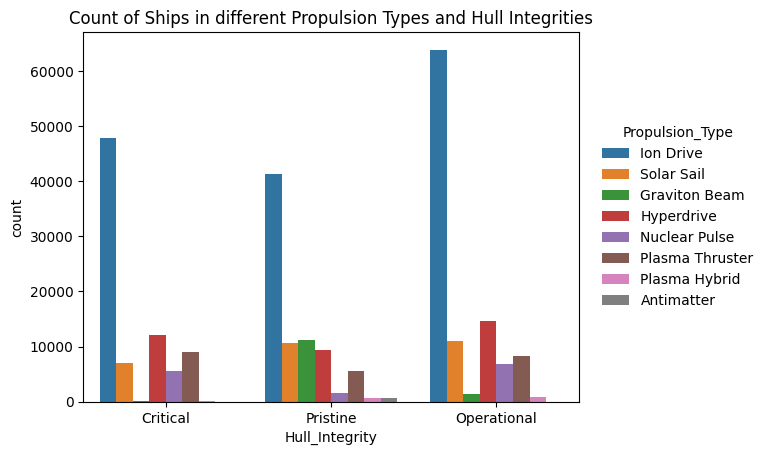

In [55]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Propulsion_Type")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.title("Count of Ships in different Propulsion Types and Hull Integrities")

From this plot we can see that:
 * majority of Graviton Beam and Antimatter ships are in pristine condition
 * majority of Plasma Thruster Ships (by a tiny bit) are in critical condition

Text(0.5, 1.0, 'Count of Ships in different Ship Classes and Hull Integrities')

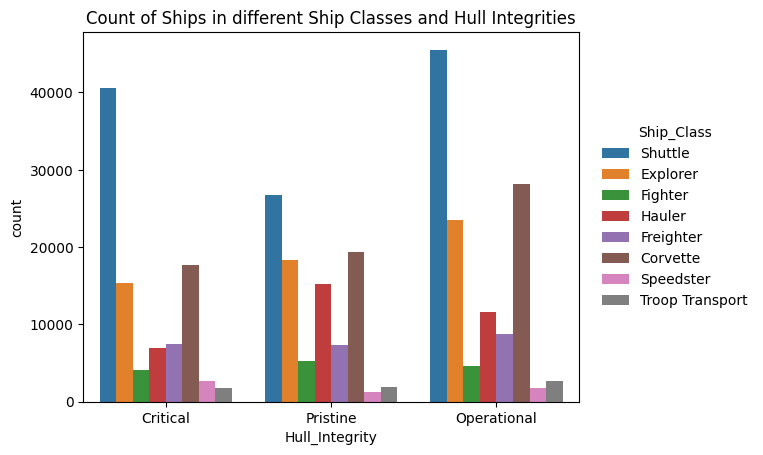

In [56]:
ax = sns.countplot(data=df_merged, x="Hull_Integrity", hue="Ship_Class")
sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.title("Count of Ships in different Ship Classes and Hull Integrities")

From this plot we can see that:
 * majority of Hauler and Fighter ships are in pristine condition
 * majority of Speedster ships are in critical condition

Text(0.5, 1.0, 'Propulsion Type distribution based on Ship Manufacturer')

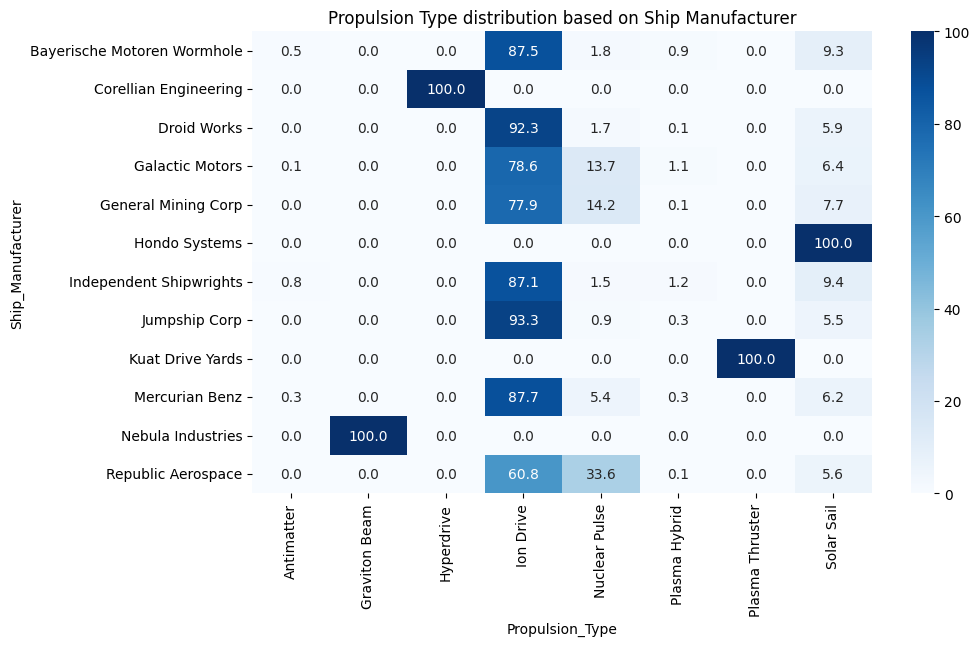

In [57]:
ct = pd.crosstab(df_merged["Ship_Manufacturer"], df_merged["Propulsion_Type"], normalize="index") * 100
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Propulsion Type distribution based on Ship Manufacturer")

Using this heatmap we can see  what propulsion types are the most common for what ship manufacturer. We can later use this information to fill in the missing values for the propulsion type by mapping the most common one for that ship manufacturer.

Text(0.5, 1.0, 'Distribution of Ships with various Recator Power across different Hull Integrities and Ship Classes')

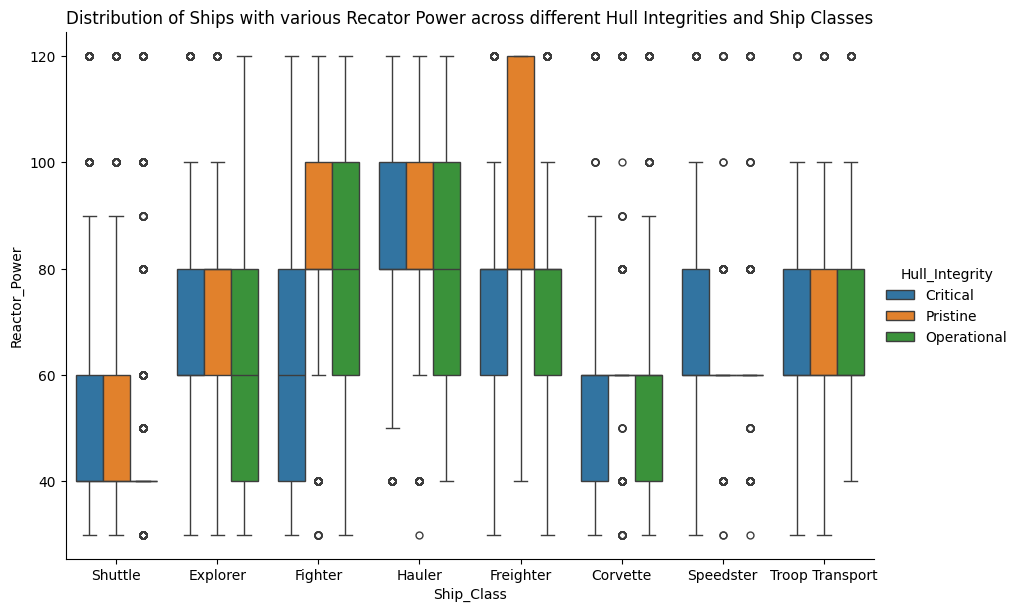

In [58]:
sns.catplot(
    data=df_merged,
    kind="box",
    x="Ship_Class",
    y="Reactor_Power",
    hue="Hull_Integrity",
    height=6,
    aspect=1.5,
    showfliers=True
)
plt.title("Distribution of Ships with various Recator Power across different Hull Integrities and Ship Classes")

Using this catplot we can filter hull integrity based on ship class and reactor power, which will be very useful during modelling.

Text(0.5, 1.0, 'Distribution of Ships with various Recator Power across different Hull Integrities and Propulsion Types')

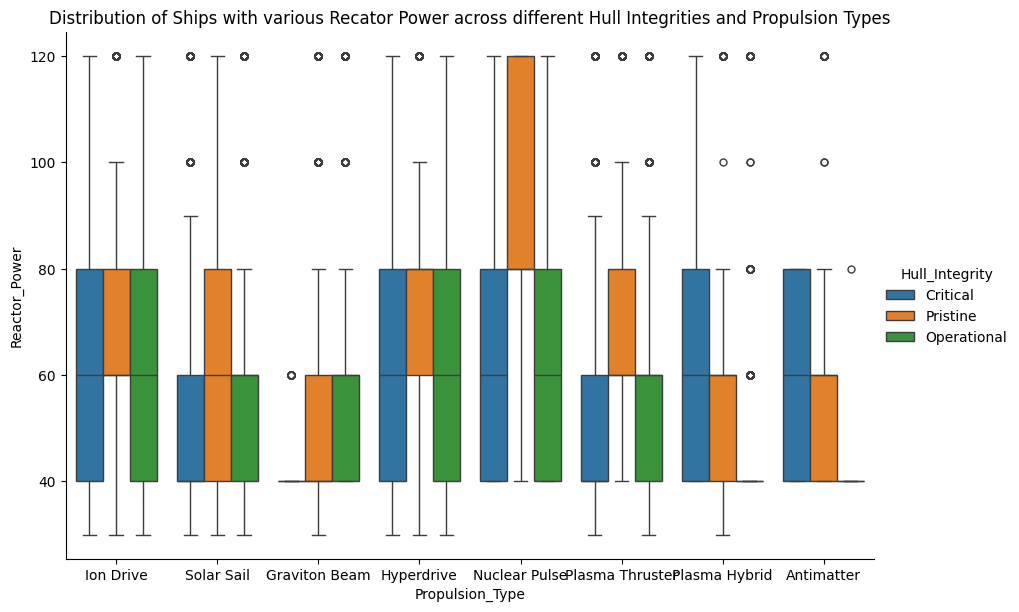

In [59]:
sns.catplot(
    data=df_merged,
    kind="box",
    x="Propulsion_Type",
    y="Reactor_Power",
    hue="Hull_Integrity",
    height=6,
    aspect=1.5,
    showfliers=True
)
plt.title("Distribution of Ships with various Recator Power across different Hull Integrities and Propulsion Types")

Using this catplot we can filter hull integrity based on propulsion type and reactor power, which will again be very useful during modelling.

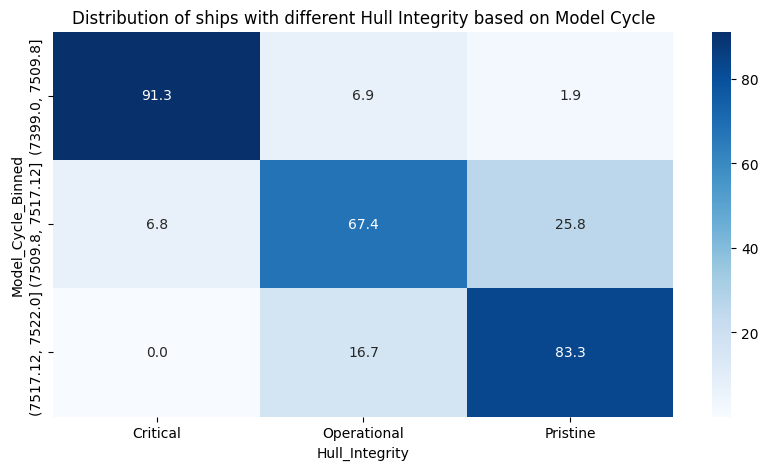

In [80]:
custom_bins = [7399, 7509.8, 7517.12, 7522]

df_merged["Model_Cycle_Binned"] = pd.cut(df_merged["Model_Cycle"], bins=custom_bins)

ct = pd.crosstab(df_merged["Model_Cycle_Binned"], df_merged["Hull_Integrity"], normalize="index") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Distribution of ships with different Hull Integrity based on Model Cycle")
plt.show()

Using the heatmap we can see the dristibution of ships with different hull integrity across different model years. It's very clear that ships below 7509.8 model cycle are very likely to be critical, while ships above 7517.12 are very likely to be in pristine condition. This filters a big chunk of data during the modelling, providing better results.

BTW if you are wondering where i took the custom bins from, its from the heatmaps with 100 bins which you didn't like, so if you want to see for yourself that they are indeed valid, go ahead...same applies to galactic credits.

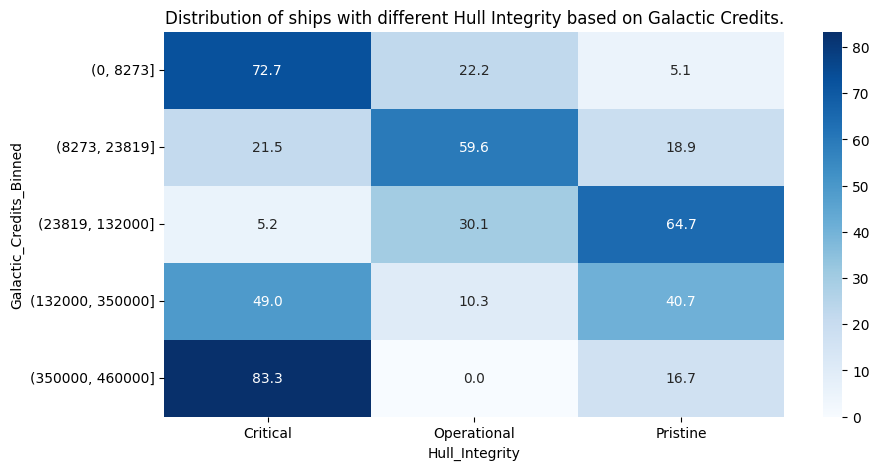

In [81]:
custom_bins=[0, 8273, 23819, 132000, 350000, 460000]

df_merged["Galactic_Credits_Binned"] = pd.cut(df_merged["Galactic_Credits"], bins=custom_bins)

ct = pd.crosstab(df_merged["Galactic_Credits_Binned"], df_merged["Hull_Integrity"], normalize="index") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Distribution of ships with different Hull Integrity based on Galactic Credits.")
plt.show()

Using the heatmap we can see the dristibution of ships with different hull integrity across different price ranges. It's very clear that ships under 8200 are mostly critical, ships above 23000 and below 132000 are mostly pristine, ships between 350000 and 460000 are again mostly critical and all the ships outside these ranges have mixed integrity.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**

In [62]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318296 entries, 0 to 368813
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Ship_ID                  318296 non-null  int64   
 1   Galactic_Credits         318296 non-null  int64   
 2   Model_Cycle              311877 non-null  float64 
 3   Ship_Manufacturer        318296 non-null  object  
 4   Sector                   318296 non-null  object  
 5   Hull_Integrity           318296 non-null  object  
 6   Reactor_Power            318296 non-null  float64 
 7   Propulsion_Type          269326 non-null  object  
 8   Ship_Class               318296 non-null  object  
 9   Model_Cycle_Binned       311877 non-null  category
 10  Galactic_Credits_Binned  318296 non-null  category
dtypes: category(2), float64(2), int64(2), object(5)
memory usage: 24.9+ MB


Since we have already removed outliers we got rid of a big chunk of data. 
Now our baseline is 318296 entries.
Missing values:
 * Model Cycle: 6419 -> missing values in 2% of all entries
 * Propulsion Type: 48970 -> missing values in 15% of all entries
 * Reactor Power: no more missing values, since when we removed outliers we also removed all the NaN entries

In [63]:
df_merged = df_merged.dropna(subset=["Model_Cycle"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 311877 entries, 0 to 368813
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Ship_ID                  311877 non-null  int64   
 1   Galactic_Credits         311877 non-null  int64   
 2   Model_Cycle              311877 non-null  float64 
 3   Ship_Manufacturer        311877 non-null  object  
 4   Sector                   311877 non-null  object  
 5   Hull_Integrity           311877 non-null  object  
 6   Reactor_Power            311877 non-null  float64 
 7   Propulsion_Type          263865 non-null  object  
 8   Ship_Class               311877 non-null  object  
 9   Model_Cycle_Binned       311877 non-null  category
 10  Galactic_Credits_Binned  311877 non-null  category
dtypes: category(2), float64(2), int64(2), object(5)
memory usage: 24.4+ MB


Since Model Cycles only miss 2% of values we can drop them without skewing with the data drastically.

In [64]:
by_mfr_mode = (
    df_merged.dropna(subset=["Ship_Manufacturer", "Propulsion_Type"])
      .groupby("Ship_Manufacturer")["Propulsion_Type"]
      .agg(lambda s: s.value_counts().idxmax())
)
global_mode = df_merged["Propulsion_Type"].mode().iloc[0]
missing = df_merged["Propulsion_Type"].isna()
df_merged.loc[missing, "Propulsion_Type"] = (
    df_merged.loc[missing, "Ship_Manufacturer"].map(by_mfr_mode).fillna(global_mode)
)

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 311877 entries, 0 to 368813
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Ship_ID                  311877 non-null  int64   
 1   Galactic_Credits         311877 non-null  int64   
 2   Model_Cycle              311877 non-null  float64 
 3   Ship_Manufacturer        311877 non-null  object  
 4   Sector                   311877 non-null  object  
 5   Hull_Integrity           311877 non-null  object  
 6   Reactor_Power            311877 non-null  float64 
 7   Propulsion_Type          311877 non-null  object  
 8   Ship_Class               311877 non-null  object  
 9   Model_Cycle_Binned       311877 non-null  category
 10  Galactic_Credits_Binned  311877 non-null  category
dtypes: category(2), float64(2), int64(2), object(5)
memory usage: 24.4+ MB


Propulsion types are the highest missing value in the dataset. We don't want to drop these since it's almost 15% of rows. And because it's still way less than 50% (which based on lectures is fine to imputate) we decided to map the most common propulsion type based on the ship manufacturer. We got this idea during the data understanding while visualizing the heatmap of Ship_Manfucaturer and Propulsion_Type.

In [65]:
df_merged = df_merged[df_merged["Galactic_Credits"] >= 0]

In [66]:
df_merged = df_merged.drop(["Model_Cycle_Binned", "Galactic_Credits_Binned"], axis=1)
df_merged.to_csv("iteration2_final.csv", sep=";", index=False)

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**

In [67]:
target = df_merged["Hull_Integrity"]

features = df_merged[["Reactor_Power", "Propulsion_Type", "Ship_Class", "Galactic_Credits", "Model_Cycle"]]


We have decided not to use the test and train split, since we aren't training the model, but it's a manual classification.

In [68]:
value = "Operational"

prediction = [value] * len(target)

In [69]:
print("The length of dataset:", len(target))

The length of dataset: 311877


In [70]:
print("Accuracy of baseline prediction:", accuracy_score(prediction, target))

Accuracy of baseline prediction: 0.3976535621414853


In [71]:
def classification_model(row):
    rp = row["Reactor_Power"]
    pt = row["Propulsion_Type"]
    sc = row["Ship_Class"]
    gc = row["Galactic_Credits"]
    mc = row["Model_Cycle"]
    
    if mc <= 7509.8: 
        return "Critical"
    
    if mc >= 7517.12:
        return "Pristine"
        
    if gc > 350000 and gc < 460000:
        return "Critical"
        
    if gc >= 23819 and gc < 132000:
        return "Pristine"
        
    if gc <= 8273:
        return "Critical"
        
    if pt in ("Graviton Beam", "Antimatter"):
        return "Pristine"
    
    if pt == "Plasma Thruster":
        if rp > 60:
            return "Pristine"
        else:  
            return "Critical"
    
    if pt == "Nuclear Pulse":
        if rp > 80: 
            return "Pristine"
        
    
    if sc == "Freighter":
        if rp >= 80:
            return "Pristine"
        else:
            return "Critical"
    
    if sc in ("Fighter", "Speedster"):
        return "Critical"

    
    return "Operational"


## Business logic behind the manual classification model

The goal of this manual model is to give Nebula Brokerage a simple and explainable way to classify each ship as **Critical**, **Operational**, or **Pristine** for sales, pricing, and risk screening. The rules are evaluated from top to bottom, so each ship receives exactly one final condition label.

The logic follows a business-first approach. We first use **Model_Cycle** and **Galactic_Credits** as the main indicators, because they reflect the ship’s age and market value. We then use **Propulsion_Type** and **Reactor_Power** as technical indicators to refine the decision in cases where price and age alone are not enough. **Ship_Class** is used only as an additional supporting rule.

### Rule priority

The rules are ordered by business importance:

1. **Model_Cycle first**  
   Model cycle is checked first because the age of a ship is a strong business signal of expected wear, outdated technology, and risk. Older ships are more likely to be in Critical condition, while the newest ships are more likely to be in Operational / Pristine condition.

2. **Galactic_Credits second**  
   Galactic credits are checked next because price reflects market perception of quality and condition. Very cheap ships are more likely to be damaged, outdated, or hard to maintain, while higher-value ships are more likely to be well maintained and in better condition.

3. **Propulsion_Type and Reactor_Power third**  
   After age and price, the model checks technical characteristics. Some propulsion types are associated with better ships, but reactor strength must also be considered, because an advanced propulsion system with weak power support may still indicate poor condition.

4. **Ship_Class last**  
   Ship class is treated as a supporting business rule rather than a core predictor. It helps refine the decision for specific categories such as Freighters, Fighters, and Speedsters when class-based patterns are visible in the analysis.

### Detailed rule logic

#### 1. Rules based on Model_Cycle
- If `Model_Cycle <= 7509.8`, classify the ship as **Critical**.  
  Business logic: older ships are more likely to suffer from wear, outdated components, and higher technical risk.

- If `Model_Cycle >= 7517.12`, classify the ship as **Pristine**.  
  Business logic: the newest ships are more likely to have modern components, lower wear, and better overall condition.

#### 2. Rules based on Galactic_Credits
- If `350000 < Galactic_Credits < 460000`, classify the ship as **Critical**.  
  Business logic: this unusual high price interval appears to represent abnormal ships, which may include risky, rare, or overvalued cases rather than standard healthy inventory.

- If `23819 <= Galactic_Credits < 132000`, classify the ship as **Pristine**.  
  Business logic: ships in this value range are more likely to represent strong market-quality vessels in good condition.

- If `Galactic_Credits <= 8273`, classify the ship as **Critical**.  
  Business logic: very low priced ships are more likely to be older, damaged, or less reliable.

#### 3. Rules based on Propulsion_Type and Reactor_Power
- If `Propulsion_Type` is `Graviton Beam` or `Antimatter`, classify the ship as **Pristine**.  
  Business logic: these propulsion systems are associated with more advanced ships and therefore suggest better condition.

- If `Propulsion_Type` is `Plasma Thruster` and `Reactor_Power > 60`, classify the ship as **Pristine**.  
  Business logic: plasma systems require enough power to perform reliably, so stronger reactors indicate better technical condition.

- If `Propulsion_Type` is `Plasma Thruster` and `Reactor_Power <= 60`, classify the ship as **Critical**.  
  Business logic: a weak reactor combined with a plasma propulsion system suggests underperformance or technical stress.

- If `Propulsion_Type` is `Nuclear Pulse` and `Reactor_Power > 80`, classify the ship as **Pristine**.  
  Business logic: nuclear pulse propulsion is only treated as high quality when supported by a strong reactor.

#### 4. Rules based on Ship_Class
- If `Ship_Class` is `Freighter` and `Reactor_Power >= 80`, classify the ship as **Pristine**.  
  Business logic: freighters need sufficient reactor capacity to operate safely and efficiently, so higher power indicates better condition.

- If `Ship_Class` is `Freighter` and `Reactor_Power < 80`, classify the ship as **Critical**.  
  Business logic: low reactor power in a freighter suggests the ship may struggle under operational load.

- If `Ship_Class` is `Fighter` or `Speedster`, classify the ship as **Critical**.  
  Business logic: these classes appear more frequently in the risky condition group and may be exposed to harder use and higher stress.

### Fallback rule
- If none of the rules above are triggered, classify the ship as **Operational**.

Business logic: ships that do not clearly show strong signs of either damage or excellent condition are placed in the middle category. This is a practical default because Operational represents usable but not exceptional inventory and its the most common condition.

(all thresholds and if statements are based on visualizations from the data)

In [1]:
features["Prediction"] = features.apply(lambda row: classification_model(row), axis=1)

NameError: name 'features' is not defined

In [73]:
target_names=["Critical", "Operational", "Pristine"]

print(classification_report(features["Prediction"], target, target_names=target_names))

              precision    recall  f1-score   support

    Critical       0.96      0.72      0.82    126929
 Operational       0.45      0.84      0.59     66200
    Pristine       0.86      0.67      0.76    118748

    accuracy                           0.73    311877
   macro avg       0.76      0.74      0.72    311877
weighted avg       0.81      0.73      0.75    311877



The manual classification model achieves an overall **accuracy of 73%** across 311,877 evaluated ships. It is highly reliable when predicting extreme conditions, boasting excellent precision for both **Critical (0.96)** and **Pristine (0.86)** classes. However, the model struggles with the **Operational** category; while it successfully identifies 84% of truly operational ships (high recall), its low precision of 0.45 indicates a high rate of false positives, likely due to other ship types being misclassified into this default fallback group.

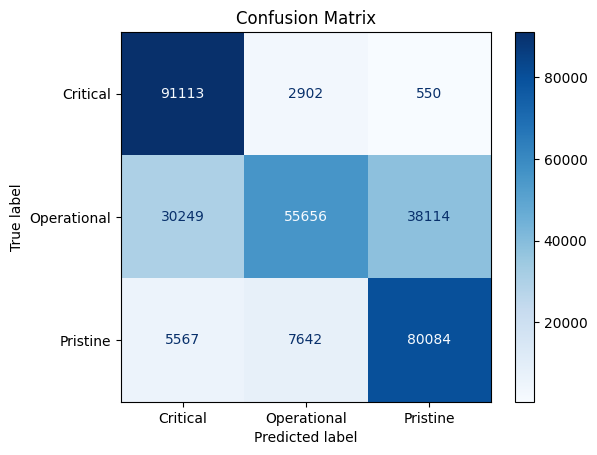

In [74]:
labels = ["Critical", "Operational", "Pristine"]

cm = confusion_matrix(target, features["Prediction"], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

This confusion matrix summarizes how well our manual classification model predicts Hull_Integrity (Critical, Operational, and Pristine)
### Structure
- Rows (True label): The actual Hull_Integrity from the dataset.
- Columns (Predicted label): The label predicted by our model.
- Each cell: Number of ships that fall into a given (true, predicted) combination.
- Diagonal cells: Correct predictions for each class.
- Off‑diagonal cells: Misclassifications.
### What the numbers show
- Critical row (top):  
  - 91,113 Critical ships correctly predicted as Critical.  
  - 2,902 Critical ships misclassified as Operational.  
  - 550 Critical ships misclassified as Pristine.  
  Critical is modeled very accurately as most predictions land on the diagonal.

- Operational row (middle):  
  - 55,656 Operational ships correctly predicted as Operational.  
  - 30,249 misclassified as Critical.  
  - 38,114 misclassified as Pristine.  
  Operational is the hardest class for the rules, it's often confused with both Critical and Pristine.

- Pristine row (bottom):  
  - 80,084 Pristine ships correctly predicted as Pristine.  
  - 5,567 misclassified as Critical.  
  - 7,642 misclassified as Operational.  
  Pristine is also modeled quite well, with relatively fewer errors compared to the number of correct predictions.
## Interpretation of data
- The model is strong on the extreme conditions (Critical and Pristine), where the rules about Model_Cycle, Galactic_Credits are obvious and predict most ships correctly.
- The middle class (Operational) where the model is the least certain, so many truly Operational Ships get labeled as Critical or Pristine. This can be, because a lot of Operational ships are spread inbetween Critical and Pristine values, due to them being so common. We would have to create way more filters to be able to catch them more precisely.

---

## 5. Evaluation

**Assessment Against Success Criteria**
The manual, hard-rule-based model achieved an overall accuracy of 73%, correctly classifying the majority of the 311,877 ships. This means we beat the baseline model by 32%. When assessing its ability to identify the most important classes, the model demonstrates an exceptional precision of 96% and a solid recall of 72% for 'Critical' ships. This means that when a ship is flagged as Critical, it is almost certainly a true Critical case, which is excellent for prioritizing urgent maintenance without wasting resources on false alarms.

The model performs well with 86% precision and 67% recall for 'Pristine' ships. It accurately identifies a large portion of ships that need no immediate attention, successfully meeting the business goal of filtering out perfectly fine vessels. However, because 'Operational' was used as the default fallback for any ship not triggering a specific rule, it has a high recall (84%) but a low precision (45%), meaning many ships were misclassified into this category.

**Key Findings and Limitations**
The current manual, hard-rule-based system is highly transparent and performs well for clearly defined edge cases. However, hard-coded rules struggle to capture complex, non-linear relationships between multiple variables, such as how propulsion type, reactor power, and model cycle interact together. Furthermore, relying on 'Operational' as a default bucket led to a high false-positive rate for that category, dragging down its precision.

A Machine Learning model would be better in the next iteration because it can automatically detect subtle patterns across all features simultaneously. It would eliminate the need for a "default" class and dynamically weigh the importance of all attributes. This would likely improve the recall for Critical ships and the precision for Operational ones, ensuring a much more robust classification system.

## Personal Contributions
### Jakub Holík (00099393)
#### Contributions
* Normalized the ship class column by handling typos and standardizing text.
* Handled outlier removal and created distribution bar plots.
* Developed count plots for ship classes.
* Plotted categorical plots (catplots) analyzing the relationship between ship class, reactor power, and hull integrity.
* Generated heatmaps visualizing hull integrity against the model cycle, and propulsion types across different ship classes.
* Designed and implemented the manual rule-based classification model.


#### Lessons learned
During this iteration I have learned how much pain in the ass it is to make a manual classification model. I had to spend hours trying to visualize relationships between different columns to find some correlation between hull intergrity and other features. Then I had to think and choose the correct thresholds to correctly classify the hull condition. To also include the ship classes, propulsion type and reactor power I took a paper notebook and wrote down some ideas and thresholds and then kept trying them out until I got better accuracy. After all that apparently the heatmaps were too cluttered, which I personally had no problem with as it beautifully visualized the thresolds and the business rules weren't suffiecient enough even though they pointed out exactly to the visualized data. So I think the most important lesson I learned during this iteration, is to keep everything dumber and actually spend less time trying to build a decent model. Next time I will use simpler visualizations, less accurate numbers to keep it simpler and aim for worse results to be able to explain them to the customer more easily.


### Timo Storny (00099699)
#### Contributions
* Formulated the Business Understanding section to set project goals and success criteria.
* Created count plots for propulsion types and categorical plots comparing propulsion type, reactor power, and hull integrity.
* Generated a heatmap correlating hull integrity with galactic credits.
* Led data preparation tasks including removing duplicates, handling negative values and NaNs, and imputing missing values for propulsion type and reactor power.
* Evaluated the model by building and interpreting the confusion matrix.

#### Lessons learned
During this iteration, I learned how to use exisitng features and their colleration to impute data. To be specific, when I was preparing the data for modelling I wanted to first remove the propulsion types with NaN values, because it was easier. But since we are supposed to use them for modelling I decided it would be nicer if I used an imputation as it might improve the model and also get us some more points for creativity. I was visualizing the correlation between ship propulsion and other feautures until I came across ship manufacturer which had the clearest correlation, so I used that. During the evaluation, building the confusion matrix demonstrated how overall accuracy can be misleading. Even though we had good accuracy, the low precision for the Operational class showed that using a fallback option creates a blind spot that ruins the reliability of that specific class.